In [40]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
df = sns.load_dataset("iris")

In [41]:
'''
Phần 1 - Thống kê mô tả & đặc trưng
'''

# 1. Đọc dữ liệu, hiển thị 5 dòng đầu; cho biết số dòng, số cột và kiểu dữ liệu của từng cột
print("Hiển thị 5 dòng đầu:\n", df.head())
print("Số dòng: ", df.shape[0])
print("Số cột: ", df.shape[1])
print("Kiểu dữ liệu của từng cột:\n", df.dtypes)

Hiển thị 5 dòng đầu:
    sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Số dòng:  150
Số cột:  5
Kiểu dữ liệu của từng cột:
 sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [42]:
# 2. Với mỗi biến số, tính: mean, median, mode, var, std, min, max, Q1, Q3 và IQR
numeric = df.select_dtypes(include = np.number)
stats = pd.DataFrame({
    "Mean": numeric.mean(),
    "Median": numeric.median(),
    "Mode": numeric.mode().iloc[0],
    "Variance": numeric.var(),
    "Std": numeric.std(),
    "Min": numeric.min(),
    "Max": numeric.max(),
    "Q1": numeric.quantile(0.25),
    "Q3": numeric.quantile(0.75),
})
stats["IQR"] = stats["Q3"] - stats["Q1"]
stats

,Mean,Median,Mode,Variance,Std,Min,Max,Q1,Q3,IQR
sepal_length,5.843333,5.80,5.0,0.685694,0.828066,4.3,7.9,5.1,6.4,1.3
sepal_width,3.057333,3.00,3.0,0.189979,0.435866,2.0,4.4,2.8,3.3,0.5
petal_length,3.758000,4.35,1.4,3.116278,1.765298,1.0,6.9,1.6,5.1,3.5
petal_width,1.199333,1.30,0.2,0.581006,0.762238,0.1,2.5,0.3,1.8,1.5


In [43]:
# 3. Theo từng nhóm (loài species): dùng groupby tính mean và std của từng biến. Nhận xét nhóm nào khác biệt nhất
group_mean = df.groupby("species").mean(numeric_only = True)
group_mean
group_std = df.groupby("species").mean(numeric_only = True)
group_std

# Nhận xét:
# - Setosa có petal_length và petal_width nhỏ nhất.
# - Virginica có petal_length và petal_width lớn nhất.
# - Versicolor nằm giữa hai nhóm còn lại.
# - Petal_length và Petal_width là hai đặc trưng giúp phân biệt các loài rõ ràng nhất.


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


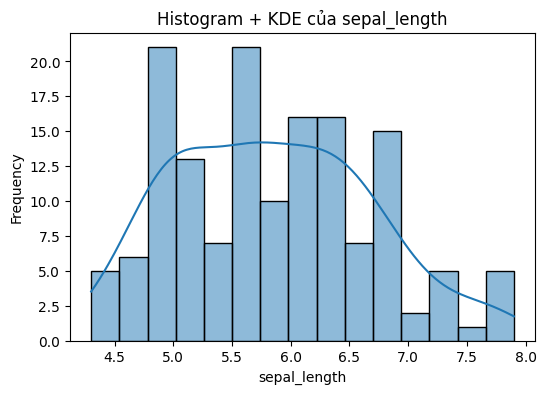

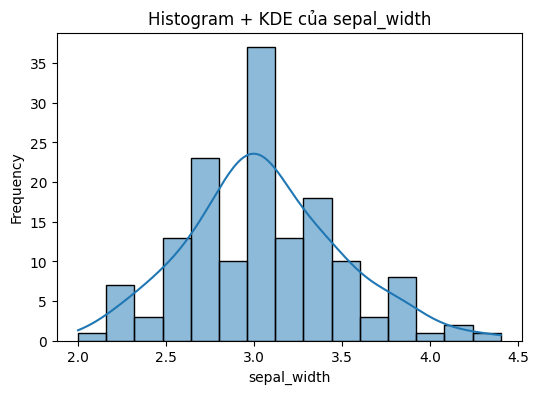

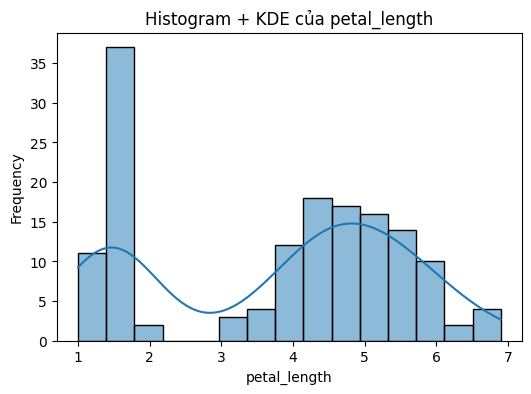

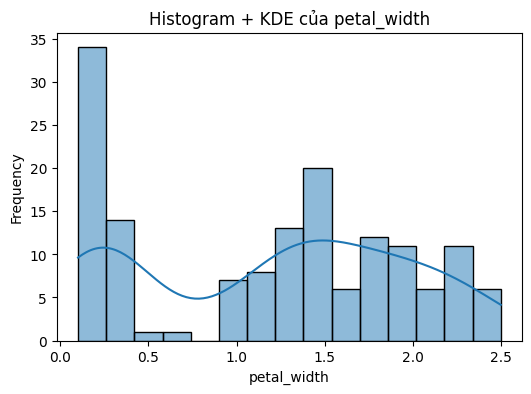

In [44]:
'''
Phần 2 - Phân phối xác suất
'''
# 1. Vẽ histogram + KDE cho từng biến số. Nhận xét hình dạng phân phối: lệch trái/phải, gần phân phối chuẩn, hay nhiều đỉnh?
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=15
    )

    plt.title(f"Histogram + KDE của {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()
# Nhận xét:
# - Các biến sepal_length và sepal_width có phân phối tương đối gần chuẩn.
# - Hai biến petal_length và petal_width có nhiều đỉnh (multimodal) do dữ liệu gồm ba loài hoa khác nhau.
# - Không thấy giá trị ngoại lai quá lớn trên histogram.


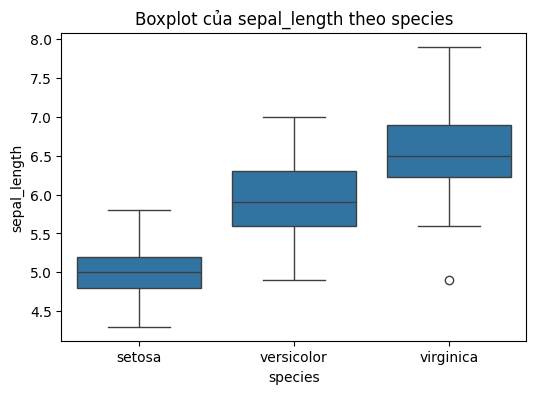

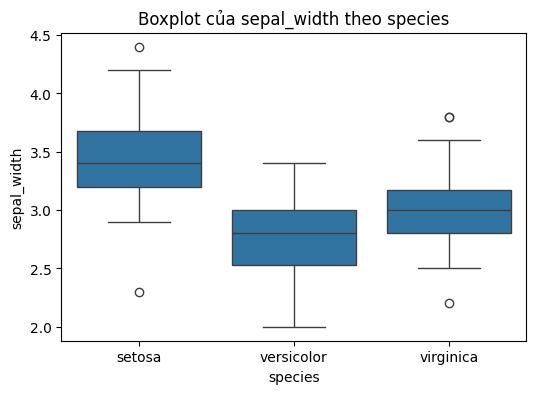

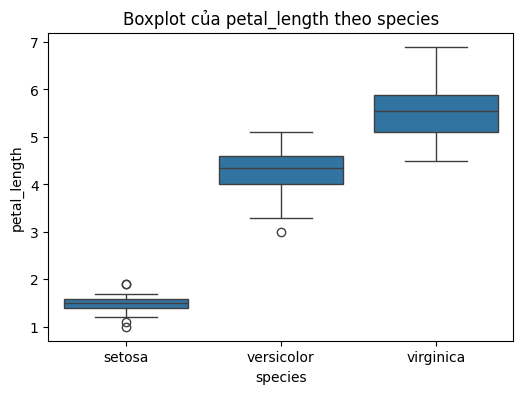

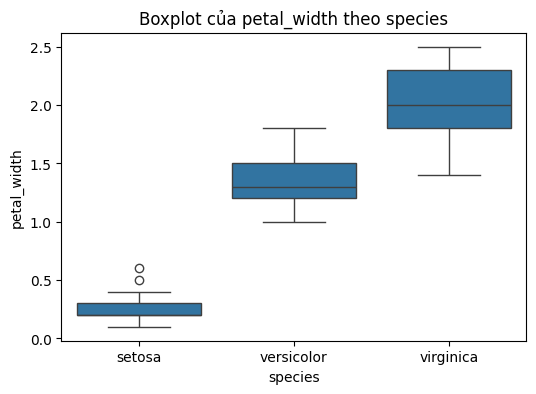

In [45]:
# 2. Vẽ boxplot từng biến theo nhóm (species) để so sánh phân phối giữa các loài
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=df,
        x="species",
        y=col
    )

    plt.title(f"Boxplot của {col} theo species")

    plt.show()
# Nhận xét
# - Setosa có petal_length và petal_width nhỏ hơn rõ rệt hai loài còn lại.
# - Virginica có giá trị lớn nhất.
# - Versicolor nằm ở giữa.
# - Hai biến petal_length và petal_width giúp phân biệt các loài rõ nhất.

3.7580000000000005
1.7652982332594667


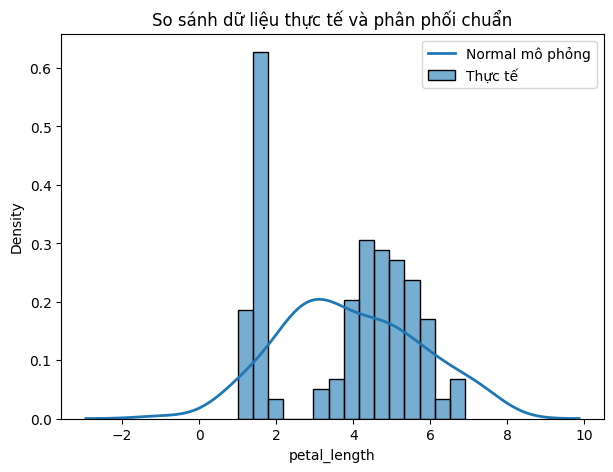

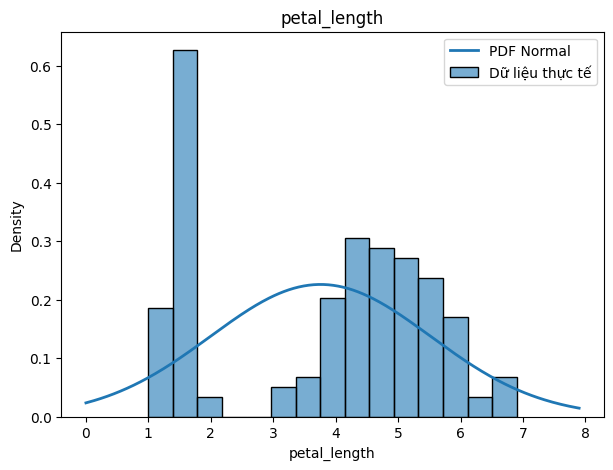

In [46]:
# 3. Mô phỏng: chọn một biến, sinh mẫu từ phân phối Normal có cùng mean và std bằng np.random.normal; vẽ chồng histogram dữ liệu thực tế với đường PDF lý thuyết. Nhận xét mức độ khớp
feature = "petal_length"
mean = df[feature].mean()
std = df[feature].std()
print(mean)
print(std)

simulated = np.random.normal(
    loc=mean,
    scale=std,
    size=len(df)
)

plt.figure(figsize=(7,5))
sns.histplot(
    df[feature],
    stat="density",
    bins=15,
    alpha=0.6,
    label="Thực tế"
)
sns.kdeplot(
    simulated,
    label="Normal mô phỏng",
    linewidth=2
)
plt.title("So sánh dữ liệu thực tế và phân phối chuẩn")
plt.legend()
plt.show()

feature = "petal_length"

mean = df[feature].mean()
std = df[feature].std()

x = np.linspace(df[feature].min()-1,
                df[feature].max()+1,
                300)

pdf = norm.pdf(x, mean, std)

plt.figure(figsize=(7,5))

sns.histplot(
    df[feature],
    stat="density",
    bins=15,
    alpha=0.6,
    label="Dữ liệu thực tế"
)

plt.plot(
    x,
    pdf,
    linewidth=2,
    label="PDF Normal"
)

plt.title(feature)
plt.legend()

plt.show()
# Nhận xét
# - Đường PDF chuẩn không khớp hoàn toàn với histogram của dữ liệu.
# - Dữ liệu petal_length có dấu hiệu nhiều đỉnh do gồm ba nhóm species khác nhau.
# - Vì vậy phân phối của dữ liệu không phải là phân phối chuẩn hoàn toàn.

In [47]:
'''
Phần 3 - Phân tích đa biến & tương quan
'''
# 1. Tính ma trận hiệp phương sai (covariance) và tương quan (correlation) giữa các biến số
cov_matrix = numeric.cov()

print("Ma trận hiệp phương sai:")
print(cov_matrix)

corr_matrix = numeric.corr()

print("Ma trận tương quan:")
print(corr_matrix)

# Nhận xét
# - Ma trận covariance cho biết mức độ biến thiên cùng nhau của các biến.
# - Ma trận correlation chuẩn hóa về khoảng [-1, 1], dễ so sánh hơn.
# - Petal_length và Petal_width có hệ số tương quan rất cao.

Ma trận hiệp phương sai:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006
Ma trận tương quan:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


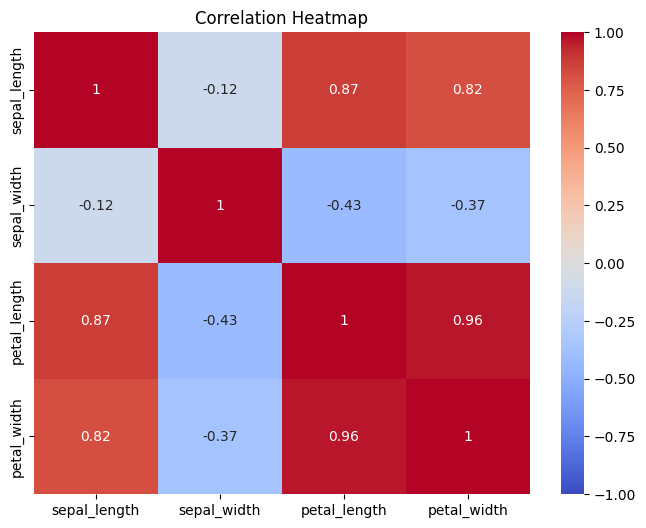

In [48]:
# 2. Vẽ heatmap tương quan; nhận xét cặp biến tương quan mạnh nhất. Có dấu hiệu đa cộng tuyến không?
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap")
plt.show()

# Nhận xét
# - Petal_length và Petal_width có tương quan mạnh nhất (≈0.96).
# - Sepal_width tương quan yếu với các biến còn lại.
# - Không có cặp biến nào tương quan âm mạnh.

# Có dấu hiệu đa cộng tuyến giữa petal_length và petal_width do hệ số tương quan khoảng 0.96.

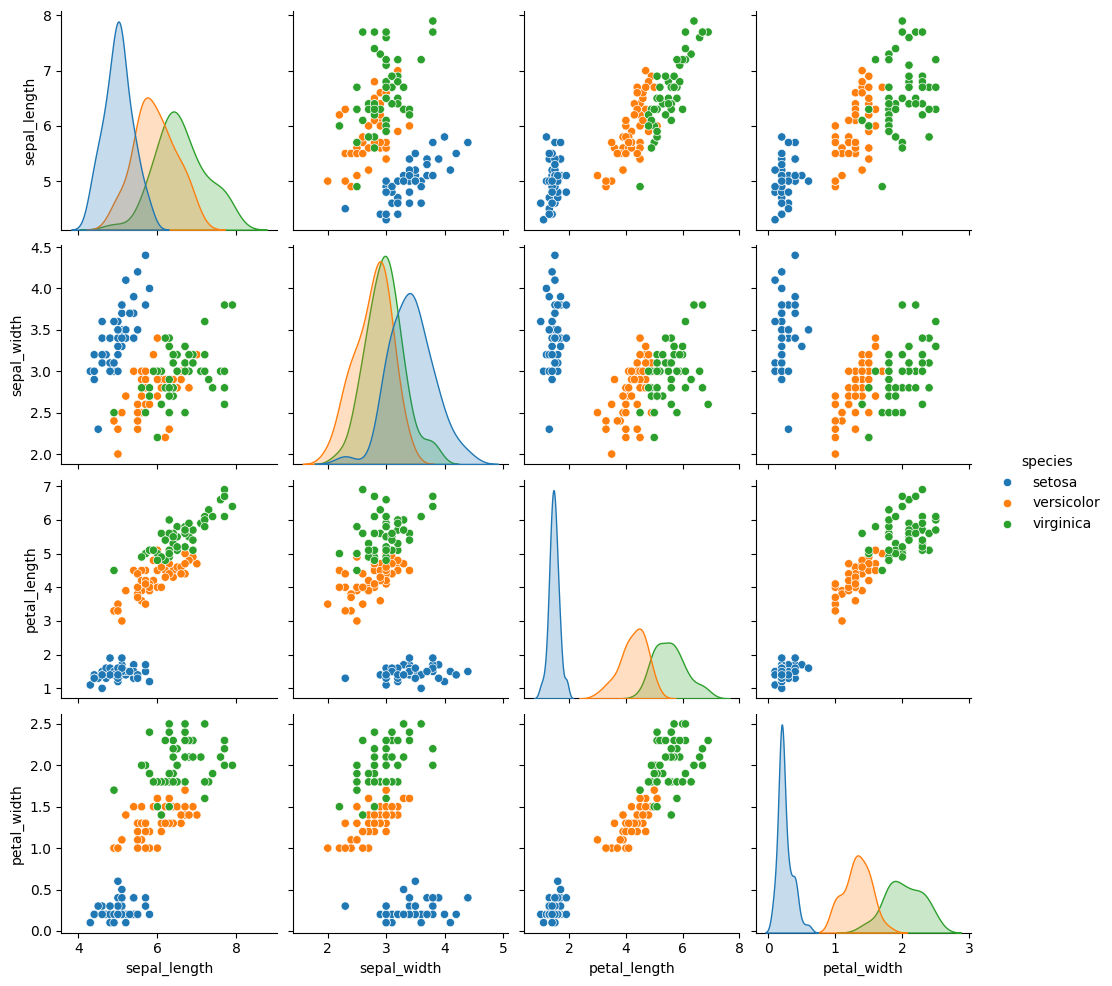

In [49]:
# 3. Vẽ pairplot (hoặc scatter theo cặp), tô màu theo species; nhận xét quan hệ giữa các biến
sns.pairplot(
    df,
    hue="species"
)
plt.show()
# Nhận xét
# - Setosa tách biệt rất rõ so với hai loài còn lại.
# - Versicolor và Virginica có một phần chồng lấn.
# - Petal_length và Petal_width giúp phân biệt ba loài tốt nhất.
# - Sepal_width ít khả năng phân biệt hơn.

In [50]:
'''
Phàn 4 - Xác suất & Định lý Bayes
'''
# 1. Viết code tính xác suất hậu nghiệm P(B|+) bằng định lý Bayes và in kết quả
# Xác suất mắc bệnh
P_B = 0.01

# Độ nhạy
P_pos_given_B = 0.99

# Dương tính giả
P_pos_given_notB = 0.05

# P(+)
P_pos = (
    P_pos_given_B * P_B
    + P_pos_given_notB * (1 - P_B)
)

# Bayes
P_B_given_pos = (
    P_pos_given_B * P_B
    / P_pos
)

print("P(B|+) =", round(P_B_given_pos,4))

# Nhận xét:
# Mặc dù xét nghiệm có độ nhạy rất cao (99%), nhưng do bệnh rất hiếm (1%) nên phần lớn kết quả dương tính đến từ người không mắc bệnh (dương tính giả). Vì vậy xác suất thực sự mắc bệnh chỉ khoảng 16.67%.

P(B|+) = 0.1667


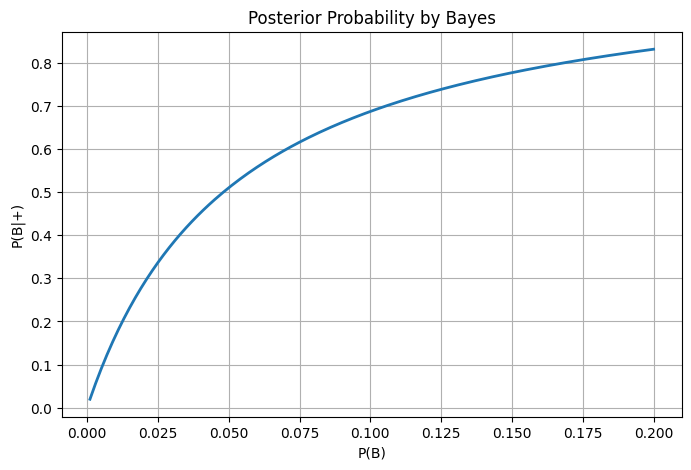

In [51]:
# 2. Khảo sát: vẽ đồ thị P(B|+) khi tỉ lệ mắc bệnh P(B) thay đổi từ 0.001 đến 0.2. Giải thích vì sao khi bệnh hiếm, hết quả lại "phản trực giác"
P_values = np.linspace(0.001,0.2,200)
posterior=[]
P_pos_given_B=0.99
P_pos_given_notB=0.05
for P_B in P_values:

    P_pos = (
        P_pos_given_B*P_B
        + P_pos_given_notB*(1-P_B)
    )

    posterior.append(
        P_pos_given_B*P_B/P_pos
    )
plt.figure(figsize=(8,5))

plt.plot(
    P_values,
    posterior,
    linewidth=2
)

plt.xlabel("P(B)")
plt.ylabel("P(B|+)")

plt.title("Posterior Probability by Bayes")

plt.grid(True)

plt.show()
# Vì sao khi bệnh hiếm thì kết quả lại "phản trực giác"?
# 100000 người chỉ 1% (1000 người) thực sự mắc bệnh. Máy xét nghiệm phát hiện đúng 99% (990 người), còn 99000 người. Nhưng 5% dương tính giả (4950 người). Tổng số dương tính 990 + 4950 = 5940 (trong đó chỉ 990 là thật). Do đó, 990/5940 = 16/7%. Đây chính là lý do nhiều người cảm thấy "phản trực giác"